### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

c:\Users\KUMAR G\Desktop\agenticAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [16]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="llama-3.1-8b-instant", temperature=0.9)
llm_groq.invoke("Hey I am kumar and i like to play cricket")

AIMessage(content="Nice to meet you, Kumar. Cricket is a great sport, and there are millions of fans all around the world who enjoy watching and playing the game. It's a physically demanding sport that requires skill, strategy, and teamwork.\n\nWhat's your favorite aspect of cricket? Do you like to bat, bowl, or field? Or are you a fan of a particular format, such as Test cricket, ODIs, or T20 cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 46, 'total_tokens': 135, 'completion_time': 0.14906113, 'completion_tokens_details': None, 'prompt_time': 0.008394807, 'prompt_tokens_details': None, 'queue_time': 0.047886522, 'total_time': 0.157455937}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb3bc-7a17-72e0-8835-60fea7ccb637-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

### We Will start With Creating Nodes

In [17]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

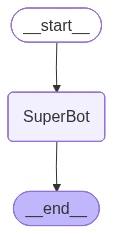

In [18]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [19]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is kumar And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is kumar And I like cricket', additional_kwargs={}, response_metadata={}, id='1eef4d4f-9c7c-4923-9c11-efca71f566a3'),
  AIMessage(content="Namaste Kumar. It's great to hear that you like cricket. Cricket is one of the most popular sports in the world, and it's enjoyed by millions of people. Which aspect of cricket do you enjoy the most - watching it, playing it, or perhaps following the stats?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 46, 'total_tokens': 104, 'completion_time': 0.107073374, 'completion_tokens_details': None, 'prompt_time': 0.002337895, 'prompt_tokens_details': None, 'queue_time': 0.046246585, 'total_time': 0.109411269}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb3bc-c7bd-7181-a1e9-0dad24270d4a-0', tool_calls=[], inval

#### Streaming The responses

In [20]:
for event in graph_builder.stream({"messages":"Hello My name is Kumar and I like cricket"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="Hello Kumar, it's great to meet you. Cricket is a fantastic sport, and it's wonderful that you enjoy it. Are you an avid follower of international cricket or do you have a favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 44, 'total_tokens': 88, 'completion_time': 0.081423581, 'completion_tokens_details': None, 'prompt_time': 0.010177332, 'prompt_tokens_details': None, 'queue_time': 0.056567539, 'total_time': 0.091600913}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb3bc-dae7-7af0-9494-9a5f2c114fbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 44, 'total_tokens': 88})]}}
